In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

print("Week 6 started successfully!")

Week 6 started successfully!


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of samples: 150
Number of features: 4


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed!")

Data scaling completed!


In [5]:
k_values = range(1, 16)
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    knn_accuracies.append(accuracy)

print("KNN testing completed!")

KNN testing completed!


In [6]:
best_k = k_values[np.argmax(knn_accuracies)]
best_accuracy = max(knn_accuracies)

print("Best K value:", best_k)
print("Best KNN Accuracy:", round(best_accuracy * 100, 2), "%")

Best K value: 1
Best KNN Accuracy: 96.67 %


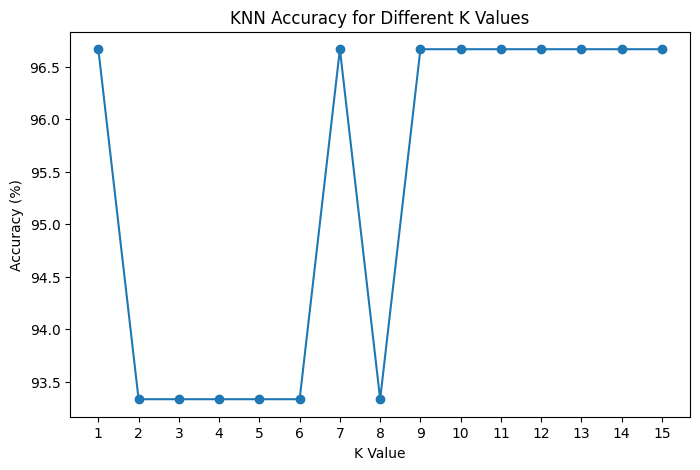

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    [a * 100 for a in knn_accuracies],
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(list(k_values))

plt.show()

In [8]:
improved_knn = KNeighborsClassifier(n_neighbors=best_k)

improved_knn.fit(X_train_scaled, y_train)

improved_predictions = improved_knn.predict(X_test_scaled)

improved_accuracy = accuracy_score(
    y_test,
    improved_predictions
)

print(
    "Improved KNN Accuracy:",
    round(improved_accuracy * 100, 2),
    "%"
)

Improved KNN Accuracy: 96.67 %


In [9]:
print("================================")
print("       WEEK 6 FINAL RESULT")
print("================================")

print("Best K:", best_k)
print(
    "Improved KNN Accuracy:",
    round(improved_accuracy * 100, 2),
    "%"
)

       WEEK 6 FINAL RESULT
Best K: 1
Improved KNN Accuracy: 96.67 %


In [10]:
wrong_indices = np.where(
    y_test != improved_predictions
)[0]

print(
    "Number of misclassified samples:",
    len(wrong_indices)
)

Number of misclassified samples: 1


In [11]:
for i in wrong_indices:
    print(
        "Actual:",
        iris.target_names[y_test[i]],
        "| Predicted:",
        iris.target_names[improved_predictions[i]]
    )

Actual: virginica | Predicted: versicolor


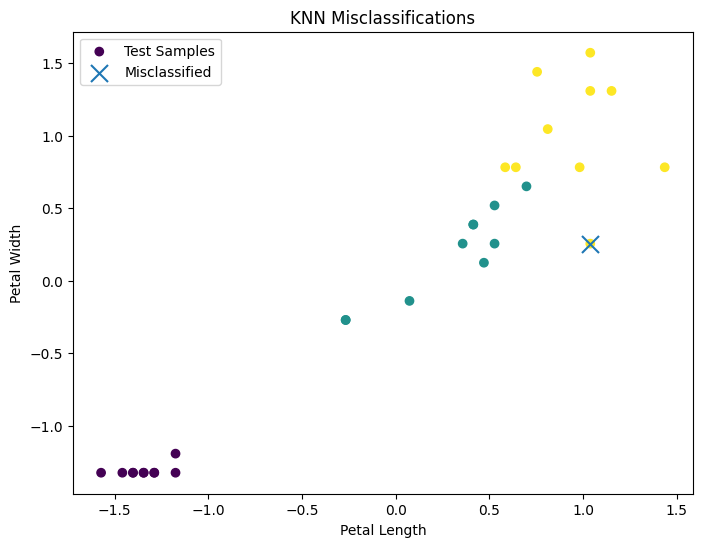

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_scaled[:, 2],
    X_test_scaled[:, 3],
    c=y_test,
    marker="o",
    label="Test Samples"
)

if len(wrong_indices) > 0:
    plt.scatter(
        X_test_scaled[wrong_indices, 2],
        X_test_scaled[wrong_indices, 3],
        marker="x",
        s=150,
        label="Misclassified"
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Misclassifications")
plt.legend()

plt.show()

In [13]:
comparison = pd.DataFrame({
    "Actual": iris.target_names[y_test],
    "Predicted": iris.target_names[improved_predictions]
})

comparison

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [14]:
cm = confusion_matrix(
    y_test,
    improved_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [15]:
print("================================")
print("       WEEK 7 FINAL RESULTS")
print("================================")

print("Total test samples:", len(y_test))
print(
    "Correct predictions:",
    np.sum(y_test == improved_predictions)
)
print(
    "Wrong predictions:",
    np.sum(y_test != improved_predictions)
)
print(
    "Accuracy:",
    round(improved_accuracy * 100, 2),
    "%"
)

       WEEK 7 FINAL RESULTS
Total test samples: 30
Correct predictions: 29
Wrong predictions: 1
Accuracy: 96.67 %


In [16]:
import joblib

joblib.dump(improved_knn, "improved_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [17]:
results = pd.DataFrame({
    "Model": ["Improved KNN"],
    "Accuracy": [improved_accuracy * 100],
    "Misclassified": [len(wrong_indices)]
})

results

,Model,Accuracy,Misclassified
0,Improved KNN,96.666667,1


In [18]:
import joblib

joblib.dump(improved_knn, "improved_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [19]:
!pip install joblib

In [20]:
print("====================================")
print("       WEEK 6 & WEEK 7 COMPLETE")
print("====================================")

print("Best K:", best_k)
print("Final Accuracy:", round(improved_accuracy * 100, 2), "%")
print("Correct Predictions:", np.sum(y_test == improved_predictions))
print("Misclassified Samples:", len(wrong_indices))

       WEEK 6 & WEEK 7 COMPLETE
Best K: 1
Final Accuracy: 96.67 %
Correct Predictions: 29
Misclassified Samples: 1
